In [1]:
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs, re, im
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt

# Funções Auxiliares

In [2]:
s, k = sp.symbols('s k')
ganho = k

## Função para receber coeficientes e transformar em polinômio

In [3]:
def polinomio(entrada):
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []
    
    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]
        
        # Pula coeficientes que são zero
        if coef == "0":
            continue
            
        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"
            
        lista_polinomio.append(termo)
        
    return " + ".join(lista_polinomio)


## Função para calcular passo 4

In [4]:
def lgr_real(polos, zeros):
    # Manter apenas polos e zeros reais
    for polo in polos:
        if(im(polo) != 0):
            polos.pop(polo)
    for zero in zeros:
        if(im(zero) != 0):
            zeros.pop(zero)

## Função para passo 07

In [5]:
def plot_assintotas(ax, ponto, angulos, comprimento=10):
    x0, y0 = ponto

    for angulo in angulos:
        theta = np.radians(angulo)

        x1 = x0 + comprimento * np.cos(theta)
        y1 = y0 + comprimento * np.sin(theta)

        ax.plot([x0, x1], [y0, y1], linestyle='--')

    ax.scatter(x0, y0, color='black', zorder=3, label = "sigma")
    ax.legend()


# Passo a passo LGR

In [114]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...


TransferFunction(1, s**3 + 8*s**2 + 32*s, s)

In [115]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...


TransferFunction(1, s + 4, s)

In [116]:
ft = Series(G, H).doit()
sp.expand(ft.den)

s**4 + 12*s**3 + 64*s**2 + 128*s

## Passo 01 - Escrever polinômio característico

In [117]:
print("1 + K*")
ft

1 + K*


TransferFunction(1, (s + 4)*(s**3 + 8*s**2 + 32*s), s)

## Passo 02 = Fatorar polinômio - NÂO FATORA POLO COMPLEXO

In [118]:
fatorado = sp.factor(ft)
print("1 + K*")
fatorado

1 + K*


TransferFunction(1, s*(s + 4)*(s**2 + 8*s + 32), s)

# Passo 3 - Polos e Zeros de malha aberta

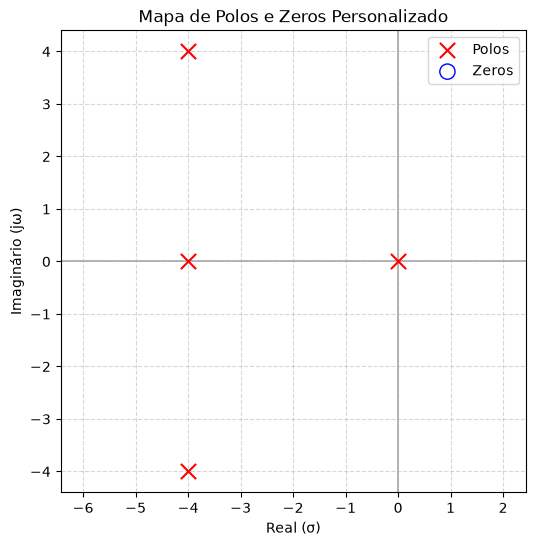

In [119]:
# 1. Extrai as coordenadas numéricas reais e imaginárias do SymPy
zeros, polos = pole_zero_numerical_data(fatorado)

def grafico_base():
    # 2. Cria o gráfico nativo no Matplotlib
    fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

    # Desenha os Polos (X vermelho) e Zeros (O azul)
    ax.scatter([p.real for p in polos], [p.imag for p in polos], 
            marker='x', color='red', s=120, label='Polos', zorder=3)
    ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
            marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

    ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
    ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Real (σ)')
    ax.set_ylabel('Imaginário (jω)')
    ax.set_title('Mapa de Polos e Zeros Personalizado')
    ax.axis('equal') # Garante proporção 1:1 perfeita no plano complexo
    ax.legend()
    return ax


grafico_base()
plt.show()

## Passo 04 - Assinalar segmentos do eixo real LGR

In [120]:
def lgr_real(polos, zeros, grande = -20):
    # Manter apenas polos e zeros reais
    polos_reais = [polo for polo in polos if polo.imag == 0]
    zeros_reais = [zero for zero in zeros if zero.imag == 0]

    polos_zeros = polos_reais + zeros_reais
    polos_zeros.sort(reverse=True)
    i = 1
    linhas = []
    for ponto in polos_zeros:
        if(i % 2 == 1):
            inicio = ponto
        else:
            final = ponto
            linhas.append([inicio, final])
        i+=1
    if(i % 2 == 0): # Terminou com linha até o infinito
        linhas.append([inicio, grande])
    return linhas
lgr_real(polos, zeros)

[[0.0, -4.0]]

In [123]:
def passo04():
    ax = grafico_base()

    for linha in lgr_real(polos, zeros):
        ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink', label='Trecho do LGR') 

    plt.legend()
    return ax

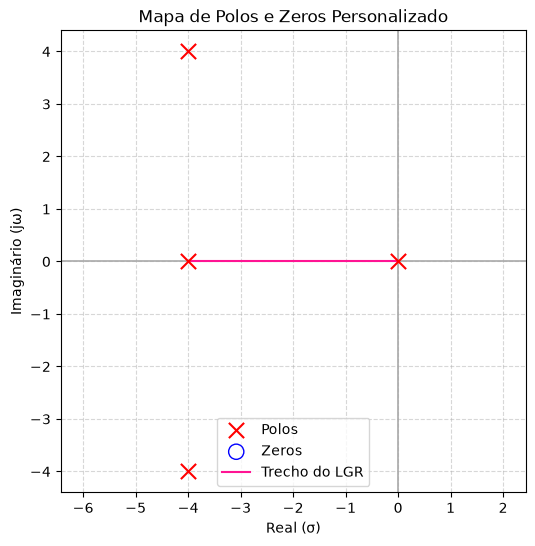

In [124]:
passo04()
plt.show()

## Passo 05 - Determinar número de lugares separados

In [125]:
n_polos = len(polos)
n_zeros = len(zeros)
if(n_polos >= n_zeros):
    ls = n_polos
else:
    ls = n_zeros
print(f"O número de lugares separados é {ls}")

O número de lugares separados é 4


## Passo 06 - LGR é simétrico em relação ao eixo real

## Passo 07 - Número de seguimentos LGR em direção a zeros infinitos

In [126]:
n_assintotas = n_polos - n_zeros

# Cálculo de sigma
soma_real = 0
for polo in polos:
    parte_real = re(polo)
    soma_real += parte_real
for zero in zeros:
    parte_real = re(zero)
    soma_real -= parte_real

sigma = soma_real/(n_polos - n_zeros)

#Cálculo do angulo das assintotas
angulos_assintotas = []
for q in range(n_polos - n_zeros): # 0, 1, 2, ..., (np - nz- 1)
    phi = (2*q + 1) *180/(n_polos - n_zeros)
    angulos_assintotas.append(phi)

In [127]:
print(f"{n_assintotas} assintotas para zeros infinitos")
print(f"As assintotas são centralizadas em {sigma}")
print(f"As assintotas tem ângulo: {angulos_assintotas}")

4 assintotas para zeros infinitos
As assintotas são centralizadas em -3.00000000000000
As assintotas tem ângulo: [45.0, 135.0, 225.0, 315.0]


In [128]:
def passo07():
    ax = passo04()

    plot_assintotas(ax, (sigma, 0), angulos_assintotas, 10)
    return ax

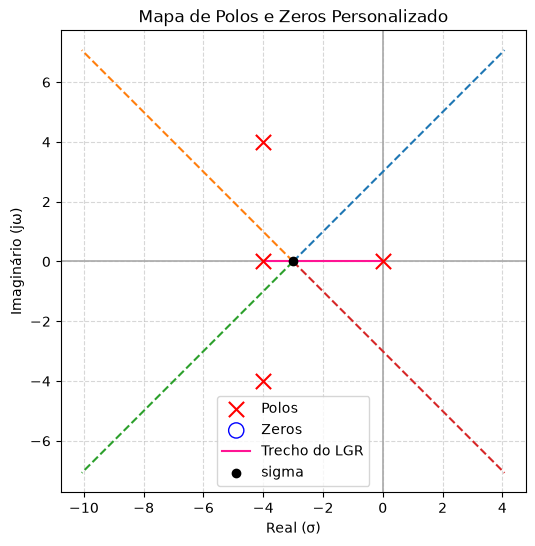

In [129]:
passo07()
plt.show()

## Passo 08 - Ponto de saída sobre o eixo real

In [130]:
# Inverso negativo: -1 / ft
# Converte o objeto de controle em uma expressão matemática comum do SymPy
ft_expressao = ft.to_expr()

# Agora você pode usar o sp.cancel() e fazer operações com números normalmente
ft_inverso_negativo = sp.cancel(-1 / ft_expressao)
ft_inverso_negativo

-s**4 - 12*s**3 - 64*s**2 - 128*s

In [131]:
df = sp.diff(ft_inverso_negativo, s)

raizes = sp.solve(df, s)
raizes_numericas = [complex(r.evalf()) for r in raizes]
raizes_numericas

[(-3.711659172376536-2.553306940593506j),
 (-3.711659172376536+2.553306940593506j),
 (-1.5766816552469278+0j)]

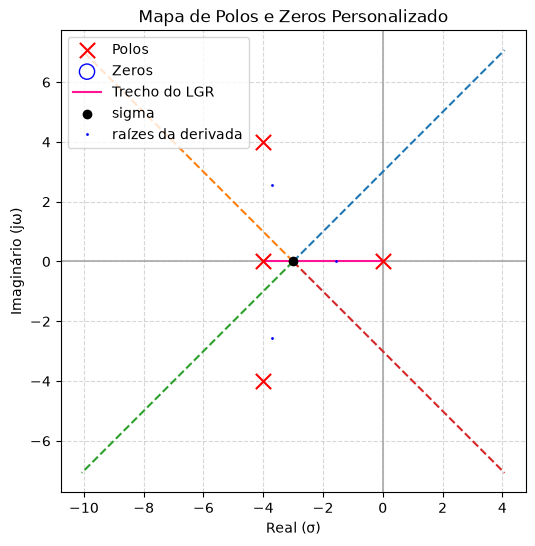

In [132]:
ax = passo07()

x = [r.real for r in raizes_numericas]
y = [r.imag for r in raizes_numericas]

ax.plot(x, y, 'b.', markersize=2, label = "raízes da derivada")

plt.legend()
plt.show()

In [133]:
ponto_saida = []
linhas = lgr_real(polos, zeros)

for raiz in raizes_numericas:
    if im(raiz) == 0:
        for linha in linhas:
            if re(raiz) > linha[1] and re(raiz) < linha[0]:
               ponto_saida.append(raiz)
ponto_saida

[(-1.5766816552469278+0j)]

## Passo 09 - Usar Routh-Hurwirtz para determinar cruzamento com eixo imaginário

In [137]:
def tabela_routh_lgr(G, H, k):
    s = G.var

    # Equação característica:
    # D_G(s)*D_H(s) + k*N_G(s)*N_H(s) = 0

    polinomio = sp.expand(
        G.den * H.den +
        k * G.num * H.num
    )

    pol = sp.Poly(polinomio, s)

    coef = pol.all_coeffs()

    n = len(coef) - 1
    colunas = (n + 2) // 2

    tabela = sp.zeros(n + 1, colunas)

    tabela[0, :len(coef[0::2])] = sp.Matrix([coef[0::2]])
    tabela[1, :len(coef[1::2])] = sp.Matrix([coef[1::2]])

    for i in range(2, n + 1):
        for j in range(colunas - 1):
            a = tabela[i - 2, 0]
            b = tabela[i - 2, j + 1]
            c = tabela[i - 1, 0]
            d = tabela[i - 1, j + 1]

            tabela[i, j] = sp.simplify((c*b - a*d) / c)

    return tabela

In [140]:
rh = tabela_routh_lgr(G, H, k)
rh

Matrix([
[           1,  64, k],
[          12, 128, 0],
[       160/3,   k, 0],
[128 - 9*k/40,   0, 0],
[           k,   0, 0]])

In [146]:
def k_criticos_positivos(R, k):
    primeira_coluna = [sp.factor(R[i, 0]) for i in range(R.rows)]

    k_criticos = []

    for elemento in primeira_coluna:

        solucoes = sp.solve(elemento, k)

        for sol in solucoes:

            # Verifica se a solução é real e positiva
            if sol.is_real and sol >= 0:
                if sol not in k_criticos:
                    k_criticos.append(sol)

    return k_criticos
Kc = k_criticos_positivos(rh, k)

In [148]:
def resolver_linha_s2(R, k_criticos, s, k):
    """
    Recebe:
        R            -> tabela de Routh
        k_criticos   -> lista de ganhos críticos
        s            -> símbolo da variável s
        k            -> símbolo do ganho

    Retorna:
        Polos encontrados ao resolver a linha s^2 para cada K crítico.
    """

    # Índice da linha s^2:
    # linha s^n -> índice 0
    # ...
    # linha s^2 -> índice n - 2
    n = R.rows - 1
    indice_s2 = n - 2

    # Verifica se existe linha s^2
    if indice_s2 < 0:
        raise ValueError("A tabela não possui uma linha s^2.")

    # Pega os elementos da linha s^2
    linha_s2 = list(R[indice_s2, :])

    # Remove zeros do final
    while linha_s2 and linha_s2[-1] == 0:
        linha_s2.pop()

    # Constrói o polinômio da linha s^2
    # Exemplo: [1, 3] -> s^2 + 3
    polinomio_s2 = sum(
        linha_s2[j] * s**(2 - 2*j)
        for j in range(len(linha_s2))
    )

    print("Linha s^2:")
    sp.pprint(polinomio_s2)

    resultados = {}

    for kc in k_criticos:

        # Substitui o ganho crítico
        polinomio_k = sp.factor(
            polinomio_s2.subs(k, kc)
        )

        # Resolve a equação da linha s^2
        polos = sp.solve(
            sp.Eq(polinomio_k, 0),
            s
        )

        resultados[kc] = polos

        print(f"\nK crítico = {kc}")
        print("Equação:")
        sp.pprint(sp.Eq(polinomio_k, 0))

        print("Polos:")
        sp.pprint(polos)

    return resultados
resolver_linha_s2(rh, Kc, s, k)

Linha s^2:
         2
    160⋅s 
k + ──────
      3   

K crítico = 5120/9
Equação:
    ⎛   2     ⎞    
160⋅⎝3⋅s  + 32⎠    
─────────────── = 0
       9           
Polos:
⎡-4⋅√6⋅ⅈ   4⋅√6⋅ⅈ⎤
⎢────────, ──────⎥
⎣   3        3   ⎦

K crítico = 0
Equação:
     2    
160⋅s     
────── = 0
  3       
Polos:
[0]


{5120/9: [-4*sqrt(6)*I/3, 4*sqrt(6)*I/3], 0: [0]}

## Passo 10 - Ângulo de partida para polos complexos e ângulo de chegada para zeros complexos

LEMBRAR DO ANGULO SER POSITIVO

In [ ]:
import sympy as sp


def angulo(v):
    """Retorna o argumento de um número complexo em graus."""
    return float(sp.deg(sp.arg(v)))


def angulo_partida(polo, polos, zeros):
    """
    Calcula o ângulo de partida de um polo complexo.

    polo  : polo de onde o ramo parte
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos outros polos
    soma_polos = 0

    for p in polos:
        if p != polo:
            soma_polos += angulo(polo - p)

    # Soma dos ângulos dos zeros
    soma_zeros = 0

    for z in zeros:
        soma_zeros += angulo(polo - z)

    # Condição de ângulo:
    # soma_zeros - (soma_polos + phi) = 180°
    phi = soma_zeros - soma_polos - 180

    # Normaliza para [-180, 180)
    phi = (phi + 180) % 360 - 180

    return phi


def angulo_chegada(zero, polos, zeros):
    """
    Calcula o ângulo de chegada em um zero complexo.

    zero  : zero onde o ramo chega
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos polos
    soma_polos = 0

    for p in polos:
        soma_polos += angulo(zero - p)

    # Soma dos ângulos dos outros zeros
    soma_zeros = 0

    for z in zeros:
        if z != zero:
            soma_zeros += angulo(zero - z)

    # Condição de ângulo:
    # (phi + soma_zeros) - soma_polos = 180°
    phi = 180 + soma_polos - soma_zeros

    # Normaliza para [-180, 180)
    phi = (phi + 180) % 360 - 180

    return phi


In [ ]:
polos_complexos = [p for p in polos if sp.im(p) != 0]
zeros_complexos = [z for z in zeros if sp.im(z) != 0]

for p in polos_complexos:
    print(
        f"Polo {p}: "
        f"ângulo de partida = {angulo_partida(p, polos, zeros):.2f}°"
    )

for z in zeros_complexos:
    print(
        f"Zero {z}: "
        f"ângulo de chegada = {angulo_chegada(z, polos, zeros):.2f}°"
    )
